# Mechanism Plausibility Checks for Feature Triage

**Docker image**: `ml4t`

**Chapter 7: Defining the Learning Task**
**Section Reference**: 7.5 — From Correlation to Causality

## Purpose

This notebook implements **lightweight falsification tests** for feature evaluation.
These tests complement the correlation-based IC analysis from Section 7.3 by checking
whether a feature-outcome association is *consistent* with a proposed mechanism.

**Important**: These checks do not identify causal effects. They are robustness
diagnostics guided by mechanism reasoning, testing one feature-outcome pair at
a time. They cannot detect multivariate confounding. Formal causal
identification is deferred to Chapter 15.

We begin with a **feature × horizon scan** that expands on the ETF results from
[`07_multiple_testing`](07_multiple_testing.ipynb), where no feature survived BH-FDR at a 5-day horizon.
The scan reveals that long-lookback momentum features (126d+) carry significant
cross-sectional information at monthly horizons — confirming the well-established
academic finding (Jegadeesh and Titman 1993, Asness et al. 2013). We then apply
the three diagnostic checks to two features selected from the scan:

- **12-1 Momentum** (12-month return skipping the most recent month): survives
  triage with actionable caveats — it carries genuine cross-sectional information
  (strongest at lag 0), does not predict Treasury returns, but concentrates in
  low-volatility regimes.
- **Short-term reversal** (negated 1-day return): fails triage — no significant
  IC at the 21-day horizon, consistent with a microstructure effect that does not
  translate to monthly predictability.

## Learning Objectives

1. Run a multi-feature, multi-horizon IC scan to identify where signal exists
2. State a proposed mechanism using DAG vocabulary (confounder, mediator, collider)
3. Implement timing placebos (shift features, examine IC half-life)
4. Run shared-driver checks (unrelated outcomes should show no effect)
5. Assess regime heterogeneity (IC stability across VIX regime partitions)
6. Interpret results as triage decisions (proceed / revise / stop)

## Book Reference

Section 7.5 applies the three core checks to two features on the `etfs` universe
with a 21-day forward return label. This notebook produces the feature scan
heatmap and dual-feature diagnostics referenced in the worked example.

**Prerequisites**: Notebooks [`05_signal_evaluation`](05_signal_evaluation.ipynb) and [`06_ic_inference`](06_ic_inference.ipynb)
introduce IC analysis; [`07_multiple_testing`](07_multiple_testing.ipynb) motivates the horizon expansion.

In [1]:
"""Mechanism Plausibility Checks for Feature Triage."""

from __future__ import annotations

import warnings
from datetime import date
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from plotly.subplots import make_subplots
from scipy import stats

from data import load_etfs, load_macro
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
START_DATE = "2010-01-01"
N_PERMUTATIONS = 200
OUTPUT_DIR = Path("07_defining_the_learning_task/output")

In [3]:
set_global_seeds(SEED)

## 1. Motivation: Why Expand the Search?

The multiple-testing scan in [`07_multiple_testing`](07_multiple_testing.ipynb) found that 0 out of 13
short-lookback features survived BH-FDR correction at a 5-day horizon on ETFs.
Two explanations are possible: the features are genuinely uninformative, or the
5-day horizon is too short for cross-sectional predictability in a 100-asset
universe. Cross-asset momentum is well-established at monthly+ horizons
(Asness, Moskowitz, and Pedersen 2013) but largely absent at weekly frequencies.

We resolve this by scanning 10 features across three horizons (5d, 21d, 63d).
This empirical scan determines which feature–horizon combinations carry signal,
and two are selected for the mechanism plausibility checks that follow.

## 2. Load Data

We use the full ETF universe (~92 non-bond assets) and load VIX from FRED macro
data for regime conditioning. Treasury ETFs are excluded from the analysis
universe but IEF is retained for the shared-driver control.

In [4]:
etfs = load_etfs()

END_DATE = date(2024, 1, 1)

etfs = etfs.filter(
    (pl.col("timestamp") >= date.fromisoformat(START_DATE)) & (pl.col("timestamp") < END_DATE)
).sort(["symbol", "timestamp"])

print(f"ETF universe: {etfs['symbol'].n_unique()} symbols, {len(etfs):,} rows")
print(f"Date range: {etfs['timestamp'].min()} to {etfs['timestamp'].max()}")

ETF universe: 100 symbols, 341,508 rows
Date range: 2010-01-04 to 2023-12-29


In [5]:
# Load VIX for regime conditioning
vix_raw = load_macro(series=["vixcls"])
vix = vix_raw.filter(
    (pl.col("timestamp") >= date.fromisoformat(START_DATE)) & (pl.col("timestamp") < END_DATE)
).drop_nulls(subset=["vixcls"])

print(f"VIX: {len(vix):,} observations")
print(f"VIX range: {vix['vixcls'].min():.1f} to {vix['vixcls'].max():.1f}")

VIX: 5,113 observations
VIX range: 9.1 to 82.7


In [6]:
# Compute Treasury 21d forward return (shared-driver control)
TREASURY_SYMBOL = "IEF"  # 7-10 Year Treasury Bond ETF
LABEL_HORIZON = 21  # days

treasury_fwd = (
    etfs.filter(pl.col("symbol") == TREASURY_SYMBOL)
    .sort("timestamp")
    .with_columns(
        (pl.col("close").shift(-LABEL_HORIZON) / pl.col("close")).log().alias("treasury_fwd_return")
    )
    .select(["timestamp", "treasury_fwd_return"])
    .drop_nulls()
)

### Compute features and labels

We compute 10 features spanning four families (momentum, reversal, trend,
volatility) and forward returns at three horizons (5d, 21d, 63d). All features
use data available at time $t$ (no lookahead). The 12-1 momentum follows the
academic convention of skipping the most recent month to avoid short-term
reversal contamination.

In [7]:
# Exclude Treasury/Bond ETFs from the analysis universe
TREASURY_SYMBOLS = ["IEF", "TLT", "SHY", "AGG", "BND", "TIP", "GOVT", "BNDX", "VGSH"]

analysis = (
    etfs.filter(~pl.col("symbol").is_in(TREASURY_SYMBOLS))
    .with_columns(
        # Daily return for volatility computation
        pl.col("close").pct_change().over("symbol").alias("daily_ret"),
    )
    .with_columns(
        # ── Momentum features ──
        (pl.col("close") / pl.col("close").shift(21).over("symbol")).log().alias("mom_21d"),
        (pl.col("close") / pl.col("close").shift(63).over("symbol")).log().alias("mom_63d"),
        (pl.col("close") / pl.col("close").shift(126).over("symbol")).log().alias("mom_126d"),
        (pl.col("close") / pl.col("close").shift(252).over("symbol")).log().alias("mom_252d"),
        # 12-1: skip most recent month (Jegadeesh-Titman convention)
        (pl.col("close").shift(21).over("symbol") / pl.col("close").shift(252).over("symbol"))
        .log()
        .alias("mom_12_1"),
        # Trailing volatility (126d, annualized)
        (pl.col("daily_ret").rolling_std(126).over("symbol") * np.sqrt(252)).alias("vol_126d"),
        # ── Reversal features ──
        (pl.col("close").shift(1).over("symbol") / pl.col("close")).log().alias("rev_1d"),
        (pl.col("close").shift(5).over("symbol") / pl.col("close")).log().alias("rev_5d"),
        # ── Trend ──
        (
            (pl.col("close") - pl.col("close").rolling_mean(200).over("symbol"))
            / pl.col("close").rolling_mean(200).over("symbol")
        ).alias("dist_200ma"),
        # ── Volatility ──
        (
            pl.col("daily_ret").rolling_std(20).over("symbol")
            / pl.col("daily_ret").rolling_std(60).over("symbol")
        ).alias("rvol_ratio"),
        # ── Forward returns (labels) ──
        (pl.col("close").shift(-5).over("symbol") / pl.col("close")).log().alias("fwd_5d"),
        (pl.col("close").shift(-21).over("symbol") / pl.col("close")).log().alias("fwd_21d"),
        (pl.col("close").shift(-63).over("symbol") / pl.col("close")).log().alias("fwd_63d"),
    )
)

In [8]:
# Risk-adjusted features and label alias (requires vol_126d from previous step)
analysis = analysis.with_columns(
    (pl.col("mom_126d") / pl.col("vol_126d")).alias("adj_mom_126d"),
    pl.col("fwd_21d").alias("forward_return"),
)

In [9]:
# Join VIX for regime conditioning
analysis = analysis.join(vix, on="timestamp", how="left").drop_nulls(subset=["vixcls"])

# Join Treasury forward return for shared-driver check
analysis = analysis.join(treasury_fwd, on="timestamp", how="left").drop_nulls(
    subset=["treasury_fwd_return"]
)

n_symbols = analysis["symbol"].n_unique()
n_dates = analysis["timestamp"].n_unique()
print(f"Analysis panel: {len(analysis):,} rows, {n_symbols} symbols, {n_dates:,} dates")
if n_dates > 0:
    print(f"Cross-section size: ~{len(analysis) // n_dates} assets per date")
else:
    print("Cross-section size: N/A (no dates after join)")

Analysis panel: 312,799 rows, 92 symbols, 3,501 dates
Cross-section size: ~89 assets per date


## 3. Cross-Sectional IC Function

We compute Spearman rank correlation between each feature and forward returns at
each date, producing a time series of ICs. This is the same IC framework from
Section 7.3.

In [10]:
def compute_cross_sectional_ic(
    df: pl.DataFrame, feature_col: str, outcome_col: str, min_obs: int = 20
) -> tuple[float, float, list[float]]:
    """Compute cross-sectional IC (Spearman) at each timestamp.

    Returns: (mean_ic, t_stat, ic_series)
    """
    groups = df.select("timestamp", feature_col, outcome_col).partition_by(
        "timestamp", as_dict=True
    )

    ic_values = []
    for _key, group in groups.items():
        if len(group) < min_obs:
            continue
        feature = group[feature_col].to_numpy()
        outcome = group[outcome_col].to_numpy()
        if np.std(feature) < 1e-10 or np.std(outcome) < 1e-10:
            continue
        ic, _ = stats.spearmanr(feature, outcome)
        if not np.isnan(ic):
            ic_values.append(ic)

    if not ic_values:
        return np.nan, np.nan, []

    ic_array = np.array(ic_values)
    mean_ic = np.mean(ic_array)
    std_ic = np.std(ic_array, ddof=1)
    t_stat = mean_ic / (std_ic / np.sqrt(len(ic_array))) if std_ic > 0 else np.nan

    return mean_ic, t_stat, ic_values

## 4. Feature × Horizon Scan

We scan 10 features across three forward-return horizons (5d, 21d, 63d) using
HAC-adjusted inference. The heatmap reveals a clear pattern: long-lookback
momentum features (126d+) carry significant cross-sectional information,
while short-term features remain noise regardless of horizon.

In [11]:
SCAN_FEATURES = [
    ("mom_21d", "21d Momentum"),
    ("mom_63d", "63d Momentum"),
    ("mom_126d", "126d Momentum"),
    ("mom_252d", "252d Momentum"),
    ("mom_12_1", "12-1 Momentum"),
    ("adj_mom_126d", "Risk-Adj. Mom."),
    ("rev_1d", "1d Reversal"),
    ("rev_5d", "5d Reversal"),
    ("dist_200ma", "Dist. 200d MA"),
    ("rvol_ratio", "Vol Ratio 20/60"),
]

SCAN_HORIZONS = [("fwd_5d", "5d"), ("fwd_21d", "21d"), ("fwd_63d", "63d")]

In [12]:
# Run scan: IC + HAC t-stat for each feature × horizon pair
scan_rows = []
for feat_col, feat_label in SCAN_FEATURES:
    for hz_col, hz_label in SCAN_HORIZONS:
        sub = analysis.drop_nulls(subset=[feat_col, hz_col])
        _, _, ic_series = compute_cross_sectional_ic(sub, feat_col, hz_col)
        if len(ic_series) < 50:
            scan_rows.append(
                {"feature": feat_label, "horizon": hz_label, "ic": np.nan, "t_hac": np.nan}
            )
            continue
        hac = compute_ic_hac_stats(ic_series)
        scan_rows.append(
            {
                "feature": feat_label,
                "horizon": hz_label,
                "ic": round(hac["mean_ic"], 4),
                "t_hac": round(hac["t_stat"], 2),
            }
        )

scan_df = pl.DataFrame(scan_rows)

In [13]:
# Heatmap: HAC t-statistics by feature × horizon
feat_labels = [f[1] for f in SCAN_FEATURES]
hz_labels = [h[1] for h in SCAN_HORIZONS]

# Build matrices for the heatmap
z_matrix = []
text_matrix = []
for feat_label in feat_labels:
    row_z = []
    row_text = []
    for hz_label in hz_labels:
        match = scan_df.filter((pl.col("feature") == feat_label) & (pl.col("horizon") == hz_label))
        t_val = match["t_hac"][0] if len(match) > 0 else np.nan
        ic_val = match["ic"][0] if len(match) > 0 else np.nan
        row_z.append(t_val if not np.isnan(t_val) else 0)
        sig = "*" if abs(t_val) > 2 else ""
        row_text.append(f"IC={ic_val:.3f}<br>t={t_val:.1f}{sig}" if not np.isnan(t_val) else "—")
    z_matrix.append(row_z)
    text_matrix.append(row_text)

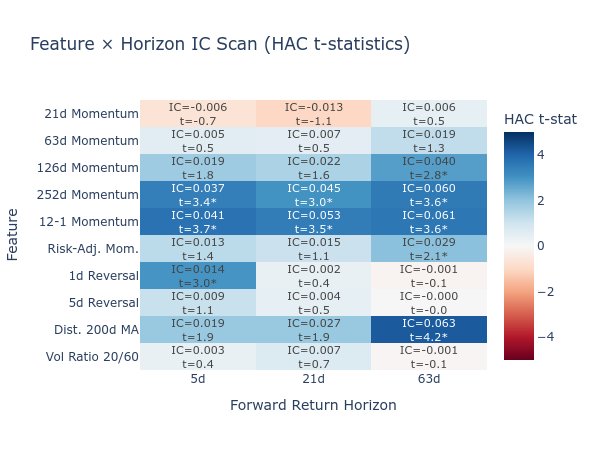

In [14]:
fig = go.Figure(
    data=go.Heatmap(
        z=z_matrix,
        x=hz_labels,
        y=feat_labels,
        text=text_matrix,
        texttemplate="%{text}",
        textfont={"size": 11},
        colorscale="RdBu",
        zmid=0,
        zmin=-5,
        zmax=5,
        colorbar=dict(title="HAC t-stat"),
    )
)
fig.update_layout(
    title="Feature × Horizon IC Scan (HAC t-statistics)",
    xaxis_title="Forward Return Horizon",
    yaxis_title="Feature",
    height=450,
    width=600,
    yaxis=dict(autorange="reversed"),
)
fig.show()

**Findings from the scan:**

1. **5-day horizon**: 252d momentum ($t = 3.4$), 12-1 momentum ($t = 3.7$), and
   1-day reversal ($t = 3.0$) reach HAC $|t| > 2$ — 3 of 10 features. The two
   momentum terms persist across horizons; the reversal hit is a short-horizon
   effect that the mechanism checks below flag as unstable.
2. **21-day horizon**: The same two features remain significant (12-1 at $t = 3.5$,
   252d at $t = 3.0$). Shorter momentum (21d, 63d) and all non-momentum features
   remain noise.
3. **63-day horizon**: Signal strengthens. 126d, 252d, 12-1, and distance from
   200d MA all reach significance. Risk-adjusted momentum becomes borderline
   significant.
4. **Short-term features**: 5d reversal and the vol ratio show no signal at any
   horizon, and 1d reversal is significant only at the 5d horizon ($t = 3.0$)
   before failing the mechanism checks below — the microstructure reversal
   effect does not translate into stable cross-sectional predictability here.

The pattern is consistent with well-established findings on cross-asset momentum:
the effect requires long lookbacks (6–12 months) and manifests at monthly+
horizons.

### Feature selection for diagnostic deep-dive

We select two features for the mechanism plausibility checks, chosen to
illustrate contrasting triage outcomes:

- **12-1 Momentum** (IC = 0.053, HAC $t$ = 3.5 at 21d): The strongest signal
  in the scan. Follows the Jegadeesh–Titman convention of skipping the most
  recent month to separate momentum from short-term reversal. The question:
  does it survive mechanism checks, or is the signal driven by a confound?
- **1-day Reversal** (IC = 0.001, HAC $t$ = 0.4 at 21d; a raw $t = 3.0$ at 5d
  that vanishes by 21d and flips sign across VIX regimes): a near-null,
  regime-driven baseline. We expect the mechanism checks to return STOP,
  confirming the framework rejects an unstable signal even when the raw
  short-horizon t-stat looks significant.

In [15]:
# Selected features for deep diagnostics
FEATURES = {
    "mom_12_1": "12-1 Momentum",
    "rev_1d": "1-day Reversal",
}

## 5. Mechanism Hypotheses

Before running diagnostics, we state the assumed causal mechanism for each
feature. This structures the interpretation of the checks.

### Feature A: 12-1 Momentum

The 12-1 momentum signal (return from $t-252$ to $t-21$) is attributed to
behavioral underreaction: investors are slow to incorporate information, so
past winners continue to outperform. The alternative: momentum proxies a
risk-on/risk-off regime rather than encoding timely cross-sectional information.

```
       Volatility Regime (VIX)
            /        \
           v          v
    12-1 Momentum -->?  Forward Return
```

### Feature B: 1-day Reversal

Negated 1-day return. The hypothesized mechanism is microstructure-driven mean
reversion: temporary price dislocations reverse within days. At a 21-day
horizon, this mechanism should have no power — the effect decays too quickly.

```
      Microstructure Friction
            |
            v
      1-day Return  -->?  21-day Forward Return
```

### Why run these checks?

These checks cost minutes; building a full model pipeline costs chapters.
Their primary value is **catching dead features early** (reversal correctly
gets STOP) and **generating actionable diagnostics** (momentum's regime
concentration informs Ch12+ modeling choices).

**REVISE is the expected outcome, not failure.** In efficient markets,
cross-sectional ICs are small ($\sim$0.03–0.05) and HAC-adjusted significance is
conservative. Few single features will cleanly pass all three bivariate
checks. The diagnostic information — *where* and *when* a feature works —
matters more than the triage label.

## 6. Baseline IC (HAC-Adjusted)

We report the HAC-adjusted IC for both features at the 21-day horizon. This
establishes the baseline that the diagnostic checks will probe.

In [16]:
baseline = {}
for feat_col, feat_label in FEATURES.items():
    sub = analysis.drop_nulls(subset=[feat_col, "forward_return"])
    ic, t, series = compute_cross_sectional_ic(sub, feat_col, "forward_return")
    hac = compute_ic_hac_stats(series) if series else {"t_stat": np.nan, "p_value": np.nan}
    baseline[feat_col] = {"ic": ic, "t": t, "series": series, "hac": hac}

print(
    pl.DataFrame(
        {
            "feature": list(FEATURES.values()),
            "mean_ic": [f"{baseline[f]['ic']:.4f}" for f in FEATURES],
            "t_naive": [f"{baseline[f]['t']:.2f}" for f in FEATURES],
            "t_hac": [f"{baseline[f]['hac']['t_stat']:.2f}" for f in FEATURES],
            "p_hac": [f"{baseline[f]['hac']['p_value']:.4f}" for f in FEATURES],
        }
    )
)

shape: (2, 5)
┌────────────────┬─────────┬─────────┬───────┬────────┐
│ feature        ┆ mean_ic ┆ t_naive ┆ t_hac ┆ p_hac  │
│ ---            ┆ ---     ┆ ---     ┆ ---   ┆ ---    │
│ str            ┆ str     ┆ str     ┆ str   ┆ str    │
╞════════════════╪═════════╪═════════╪═══════╪════════╡
│ 12-1 Momentum  ┆ 0.0529  ┆ 9.49    ┆ 3.50  ┆ 0.0005 │
│ 1-day Reversal ┆ 0.0018  ┆ 0.37    ┆ 0.37  ┆ 0.7095 │
└────────────────┴─────────┴─────────┴───────┴────────┘


12-1 momentum shows IC = 0.053 (HAC $t$ = 3.5, $p < 0.001$) — a statistically
significant cross-sectional signal. Reversal IC is indistinguishable from zero
(HAC $t$ = 0.2). The naive t-stat for momentum is higher because it ignores
autocorrelation in the IC series; the HAC correction is more conservative but
still significant.

## 7. Reusable Diagnostic Functions

We extract each falsification test into a reusable function so we can apply
the same checks to both features systematically.

In [17]:
def run_timing_placebo(
    df: pl.DataFrame,
    feature_col: str,
    outcome_col: str = "forward_return",
    lags: list[int] | None = None,
) -> tuple[pl.DataFrame, str, str]:
    """Shift the feature backward by increasing lags and recompute IC.

    Uses HAC-adjusted inference at each lag. Reports IC half-life as a
    diagnostic rather than applying a hard decay threshold.

    Returns: (lag_results_df, result_label, interpretation_msg)
    """
    if lags is None:
        lags = [0, 5, 21, 42, 63, 126, 252]

    lag_rows = []
    for lag in lags:
        col_name = f"{feature_col}_lag{lag}"
        lagged = df.with_columns(
            pl.col(feature_col).shift(lag).over("symbol").alias(col_name)
        ).drop_nulls(subset=[col_name])
        ic, _, ic_series = compute_cross_sectional_ic(lagged, col_name, outcome_col)
        hac = compute_ic_hac_stats(ic_series) if ic_series else {"t_stat": np.nan}
        lag_rows.append({"lag": lag, "ic": ic, "t_hac": hac["t_stat"]})

    lag_df = pl.DataFrame(lag_rows)

    # IC half-life: smallest lag where |IC| drops to 50% of |IC at lag 0|
    ic_0 = lag_df.filter(pl.col("lag") == 0)["ic"][0]
    half_target = abs(ic_0) * 0.5
    half_life = None
    ics = lag_df["ic"].to_list()
    lag_vals = lag_df["lag"].to_list()
    for i in range(1, len(lag_vals)):
        if abs(ics[i]) <= half_target and abs(ics[i - 1]) > half_target:
            frac = (abs(ics[i - 1]) - half_target) / (abs(ics[i - 1]) - abs(ics[i]))
            half_life = lag_vals[i - 1] + frac * (lag_vals[i] - lag_vals[i - 1])
            break

    # Assess: does IC at lag 0 have HAC significance AND meaningful decay?
    t_0 = lag_df.filter(pl.col("lag") == 0)["t_hac"][0]
    sig_0 = abs(t_0) > 2.0 if not np.isnan(t_0) else False

    # Check for IC increasing at DISTANT lags (>= 42d, well beyond any lookback).
    # Only flag if the increase is substantial — noise at nearby lags doesn't count.
    distant = [(lag_vals[i], abs(ics[i])) for i in range(1, len(ics)) if lag_vals[i] >= 42]
    ic_increases = any(abs_ic > abs(ic_0) * 1.5 for _, abs_ic in distant)

    if sig_0 and half_life is not None:
        result = "PASS"
        msg = f"IC half-life ≈ {half_life:.0f}d (HAC t₀={t_0:.1f})"
    elif not sig_0 and abs(ic_0) < 0.005:
        result = "STOP"
        msg = f"No timely signal (IC₀={ic_0:.4f}, HAC t₀={t_0:.1f})"
    elif ic_increases:
        result = "STOP"
        msg = f"IC increases at distant lags (HAC t₀={t_0:.1f})"
    elif half_life is not None:
        result = "CAUTION"
        msg = (
            f"IC decays (half-life ≈ {half_life:.0f}d) but marginal significance (HAC t₀={t_0:.1f})"
        )
    else:
        ic_range = [abs(ic) for ic in ics]
        result = "CAUTION"
        msg = (
            f"IC persists without clear decay; |IC| range "
            f"[{min(ic_range):.4f}, {max(ic_range):.4f}] (HAC t₀={t_0:.1f})"
        )

    return lag_df, result, msg

### Shared-Driver Check
Test whether a common exogenous factor (Treasury returns) or permutation
control explains the observed feature-outcome correlation.

In [18]:
def run_shared_driver_check(
    df: pl.DataFrame,
    feature_col: str,
    baseline_ic: float,
    n_permutations: int = 200,
    seed: int = 42,
) -> tuple[dict, str]:
    """Run shared-driver check (Treasury) and permutation control.

    The Treasury check uses a cross-sectional mean approach with HAC inference:
    at each date, compute the cross-sectional mean of the feature, then correlate
    the daily mean-feature series with Treasury forward returns. This avoids
    per-asset time-series regressions and produces a single IC series suitable
    for HAC adjustment.

    Returns: (metrics_dict, result_label)
    """
    # Shared-driver check: cross-sectional mean of feature vs Treasury fwd return
    daily_mean_feat = (
        df.group_by("timestamp")
        .agg(pl.col(feature_col).mean().alias("mean_feature"))
        .sort("timestamp")
    )
    tsy_series = (
        df.select("timestamp", "treasury_fwd_return").unique(subset=["timestamp"]).sort("timestamp")
    )
    shared = daily_mean_feat.join(tsy_series, on="timestamp", how="inner").drop_nulls()

    # Compute rolling rank correlation as an IC series for HAC.
    # The 63-day window is a quarterly convention; consecutive windows share
    # 62/63 of their data, so the effective sample size is much smaller than
    # the number of windows.  The HAC adjustment on the resulting series
    # partially accounts for this, but interpret borderline t-stats with care.
    feat_arr = shared["mean_feature"].to_numpy()
    tsy_arr = shared["treasury_fwd_return"].to_numpy()
    WINDOW = 63
    tsy_ic_series = []
    for i in range(WINDOW, len(feat_arr)):
        f_w = feat_arr[i - WINDOW : i]
        t_w = tsy_arr[i - WINDOW : i]
        if np.std(f_w) > 1e-10 and np.std(t_w) > 1e-10:
            rho, _ = stats.spearmanr(f_w, t_w)
            if not np.isnan(rho):
                tsy_ic_series.append(rho)

    if tsy_ic_series:
        hac_tsy = compute_ic_hac_stats(tsy_ic_series)
        ic_tsy = hac_tsy["mean_ic"]
        t_tsy = hac_tsy["t_stat"]
    else:
        ic_tsy, t_tsy = np.nan, np.nan
    tsy_pass = abs(t_tsy) < 2.0 if not np.isnan(t_tsy) else True

    # Permutation control (cross-sectional shuffle)
    rng = np.random.default_rng(seed)
    null_ics = []
    for _ in range(n_permutations):
        shuffled = df.with_columns(
            pl.col("forward_return")
            .shuffle(seed=rng.integers(0, 2**31))
            .over("timestamp")
            .alias("shuffled_return")
        )
        ic_perm, _, _ = compute_cross_sectional_ic(shuffled, feature_col, "shuffled_return")
        null_ics.append(ic_perm)

    null_ics = np.array(null_ics)
    perm_p = np.mean(np.abs(null_ics) >= abs(baseline_ic))
    perm_pass = perm_p < 0.05

    metrics = {
        "ic_treasury": ic_tsy,
        "t_treasury": t_tsy,
        "tsy_pass": tsy_pass,
        "perm_p": perm_p,
        "perm_pass": perm_pass,
        "n_rolling_windows": len(tsy_ic_series),
        "n_permutations": n_permutations,
    }

    if tsy_pass and perm_pass:
        result = "PASS"
    elif not tsy_pass and not perm_pass:
        result = "STOP"
    else:
        result = "CAUTION"

    return metrics, result

### Regime Heterogeneity
Partition by VIX regime and test whether signal effectiveness varies
across market states.

In [19]:
def run_regime_heterogeneity(
    df: pl.DataFrame,
    feature_col: str,
    outcome_col: str = "forward_return",
    vix_low: float = 15,
    vix_high: float = 22,
) -> tuple[list[dict], str, str]:
    """Partition by VIX regime and assess IC heterogeneity.

    This is a heterogeneity diagnostic, not a confounding test. It checks
    whether the feature-outcome association varies across market states. It
    cannot distinguish confounding from genuine effect modification.

    Uses HAC-adjusted inference at each partition. Decision logic:
    - PASS: IC maintains sign, magnitude varies < 2x
    - CAUTION: sign stable but magnitude varies >2x; OR sign flips but
      opposite-sign partition not significant (HAC |t| < 2)
    - STOP: sign flips with significant opposite AND unconditional IC ≈ 0

    Returns: (regime_results, result_label, interpretation_msg)
    """
    partitions = [
        ("Low VIX", df.filter(pl.col("vixcls") < vix_low)),
        ("Mid VIX", df.filter((pl.col("vixcls") >= vix_low) & (pl.col("vixcls") <= vix_high))),
        ("High VIX", df.filter(pl.col("vixcls") > vix_high)),
    ]

    # Unconditional IC with HAC
    ic_unc, _, ic_series_unc = compute_cross_sectional_ic(df, feature_col, outcome_col)
    hac_unc = compute_ic_hac_stats(ic_series_unc) if ic_series_unc else {"t_stat": np.nan}
    unc_sign = np.sign(ic_unc) if ic_unc != 0 else 0
    unc_sig = abs(hac_unc["t_stat"]) > 2.0 if not np.isnan(hac_unc["t_stat"]) else False

    regime_results = []
    for name, partition_df in partitions:
        ic, _, ic_series = compute_cross_sectional_ic(partition_df, feature_col, outcome_col)
        hac = compute_ic_hac_stats(ic_series) if ic_series else {"t_stat": np.nan}
        regime_results.append(
            {"regime": name, "ic": ic, "t_hac": hac["t_stat"], "n": len(partition_df)}
        )

    # Assess sign stability with HAC significance
    valid = [r for r in regime_results if not np.isnan(r["ic"])]
    has_significant_opposite = False
    has_nonsig_opposite = False

    for r in valid:
        if r["ic"] != 0 and np.sign(r["ic"]) != unc_sign:
            if not np.isnan(r["t_hac"]) and abs(r["t_hac"]) > 2.0:
                has_significant_opposite = True
            else:
                has_nonsig_opposite = True

    signs = [np.sign(r["ic"]) for r in valid if r["ic"] != 0]
    all_same_sign = len(set(signs)) <= 1 if signs else False

    if all_same_sign:
        ic_vals = [abs(r["ic"]) for r in valid if r["ic"] != 0]
        magnitude_ratio = (
            max(ic_vals) / min(ic_vals) if ic_vals and min(ic_vals) > 1e-6 else float("inf")
        )
        if magnitude_ratio < 2.0:
            result = "PASS"
            msg = "IC maintains sign and magnitude across VIX regimes"
        else:
            result = "CAUTION"
            msg = f"IC sign stable but magnitude varies {magnitude_ratio:.1f}x"
    elif has_significant_opposite and not unc_sig:
        result = "STOP"
        msg = "IC flips sign (HAC sig.) and unconditional IC ≈ 0 — aggregation artifact"
    elif has_significant_opposite and unc_sig:
        result = "CAUTION"
        msg = "IC flips sign (HAC sig.) but unconditional IC is itself significant"
    else:
        result = "CAUTION"
        msg = "IC changes sign in one regime but not significantly (HAC)"

    return regime_results, result, msg

## 8. Run All Checks on Both Features

We apply each plausibility check to 12-1 momentum and 1-day reversal, collecting
results for the comparison scorecard. All t-statistics use Newey-West (HAC)
standard errors to account for serial dependence in overlapping IC series.

### 8.1 Timing Placebo

For a rolling-window feature with lookback $L$, a $\Delta$-shifted version
shares roughly $(L - \Delta)/L$ of its inputs with the original. This creates
a mechanical floor on IC persistence. We therefore treat the IC-lag profile as
a **diagnostic** (how does IC behave as information ages?) rather than applying
a hard decay threshold. More weight should be placed on lags beyond the lookback
window.

For 12-1 momentum (lookback ~231 trading days), we extend the lag grid to
252d so the furthest lag reaches beyond the lookback window entirely.

In [20]:
timing = {}

# 12-1 Momentum: extended lag grid for long lookback (~231d)
lag_df, result, msg = run_timing_placebo(
    analysis.drop_nulls(subset=["mom_12_1", "forward_return"]),
    "mom_12_1",
    lags=[0, 5, 21, 42, 63, 126, 252],
)
timing["mom_12_1"] = {"lag_df": lag_df, "result": result, "msg": msg}
print(f"{FEATURES['mom_12_1']}: {result} — {msg}")

# 1-day Reversal: fine-grained grid for short lookback (1d)
lag_df, result, msg = run_timing_placebo(
    analysis.drop_nulls(subset=["rev_1d", "forward_return"]),
    "rev_1d",
    lags=[0, 1, 2, 5, 10, 21],
)
timing["rev_1d"] = {"lag_df": lag_df, "result": result, "msg": msg}
print(f"{FEATURES['rev_1d']}: {result} — {msg}")

12-1 Momentum: CAUTION — IC persists without clear decay; |IC| range [0.0339, 0.0529] (HAC t₀=3.5)


1-day Reversal: STOP — No timely signal (IC₀=0.0018, HAC t₀=0.4)


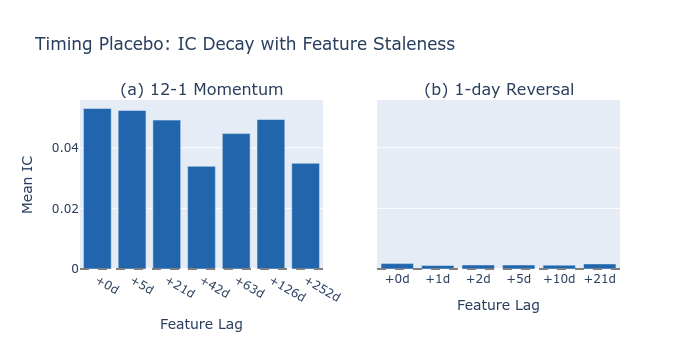

In [21]:
# Side-by-side timing placebo visualization
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["(a) 12-1 Momentum", "(b) 1-day Reversal"],
    shared_yaxes=True,
)

for i, feat_col in enumerate(FEATURES):
    lag_df = timing[feat_col]["lag_df"]
    fig.add_trace(
        go.Bar(
            x=[f"+{lag}d" for lag in lag_df["lag"].to_list()],
            y=lag_df["ic"].to_list(),
            marker_color="#2166ac",
            showlegend=False,
        ),
        row=1,
        col=i + 1,
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=i + 1)

fig.update_layout(height=350, title="Timing Placebo: IC Decay with Feature Staleness")
fig.update_yaxes(title_text="Mean IC", row=1, col=1)
fig.update_xaxes(title_text="Feature Lag", row=1, col=1)
fig.update_xaxes(title_text="Feature Lag", row=1, col=2)
fig.show()

12-1 momentum IC is strongest at lag 0 (IC = 0.053) and decays gradually to
IC ≈ 0.034 at lag 252d. The persistence is partly mechanical: with a 231-day
lookback, shifted features share most of their input data with the original.
The key diagnostic is that IC peaks at lag 0 — the most recent version of the
feature is the most informative — and even the fully stale version (lag 252d,
beyond the lookback) retains some residual predictability. Reversal IC is near
zero at all lags — there is no timely information to decay.

### 8.2 Shared-Driver Check

We test whether each feature's cross-sectional mean predicts Treasury (IEF)
21-day forward returns. For 12-1 momentum, Treasury co-movement through
risk-on/risk-off dynamics is plausible, so a non-zero Treasury IC would flag
a shared-driver concern rather than strictly falsify the mechanism.

In [22]:
n_perms = N_PERMUTATIONS

nc = {}
for feat_col in FEATURES:
    sub = analysis.drop_nulls(subset=[feat_col, "forward_return", "treasury_fwd_return"])
    metrics, result = run_shared_driver_check(
        sub, feat_col, baseline[feat_col]["ic"], n_permutations=n_perms
    )
    nc[feat_col] = {"metrics": metrics, "result": result}
    m = metrics
    print(
        f"{FEATURES[feat_col]}: {result}\n"
        f"  Treasury IC={m['ic_treasury']:.4f} (HAC t={m['t_treasury']:.2f}), "
        f"Perm p={m['perm_p']:.3f}"
    )

12-1 Momentum: PASS
  Treasury IC=0.0050 (HAC t=0.23), Perm p=0.000


1-day Reversal: CAUTION
  Treasury IC=0.0008 (HAC t=0.11), Perm p=0.385


12-1 momentum passes both checks: its cross-sectional mean does not
significantly predict Treasury returns (HAC $t$ = 0.2), and its IC is well
above the permutation null ($p < 0.001$). Reversal's Treasury IC is also
near zero, but the permutation test does not reject ($p$ = 0.38) — its
unconditional IC is indistinguishable from shuffled noise.

### 8.3 Regime Heterogeneity (VIX Regimes)

A sign flip is only flagged as STOP if the opposite-sign partition has
HAC $|t| > 2$ **and** the unconditional IC is itself not significant. In
low-power subsamples, small ICs with the wrong sign may reflect noise rather
than genuine heterogeneity. This criterion is stated here as an a priori
design choice.

In [23]:
# Tercile cutoffs; results are qualitatively similar with median splits or
# quartiles — the key diagnostic is sign stability, not exact boundaries.
VIX_LOW_THRESHOLD = 15
VIX_HIGH_THRESHOLD = 22

cond = {}
for feat_col in FEATURES:
    sub = analysis.drop_nulls(subset=[feat_col, "forward_return"])
    regime_results, result, msg = run_regime_heterogeneity(
        sub, feat_col, vix_low=VIX_LOW_THRESHOLD, vix_high=VIX_HIGH_THRESHOLD
    )
    cond[feat_col] = {"regimes": regime_results, "result": result, "msg": msg}
    print(f"\n{FEATURES[feat_col]}: {result} — {msg}")
    for r in regime_results:
        print(f"  {r['regime']:10s}: IC={r['ic']:+.4f} (HAC t={r['t_hac']:+.2f}, n={r['n']:,})")


12-1 Momentum: CAUTION — IC sign stable but magnitude varies 5.0x
  Low VIX   : IC=+0.0860 (HAC t=+3.94, n=111,994)
  Mid VIX   : IC=+0.0402 (HAC t=+1.82, n=115,811)
  High VIX  : IC=+0.0173 (HAC t=+0.60, n=61,810)



1-day Reversal: STOP — IC flips sign (HAC sig.) and unconditional IC ≈ 0 — aggregation artifact
  Low VIX   : IC=-0.0192 (HAC t=-2.63, n=113,168)
  Mid VIX   : IC=+0.0053 (HAC t=+0.69, n=127,706)
  High VIX  : IC=+0.0279 (HAC t=+2.45, n=71,833)


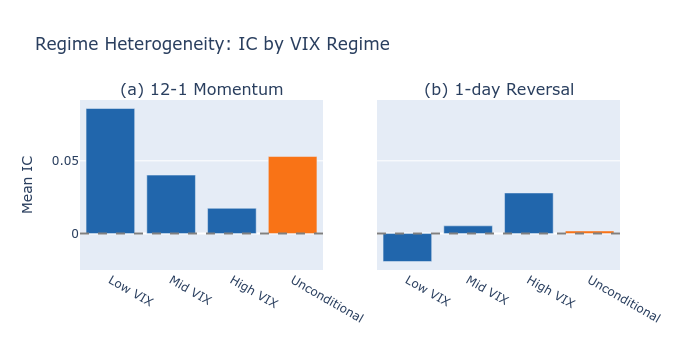

In [24]:
# Side-by-side conditioning visualization
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["(a) 12-1 Momentum", "(b) 1-day Reversal"],
    shared_yaxes=True,
)

for i, feat_col in enumerate(FEATURES):
    regimes = cond[feat_col]["regimes"]
    ic_unc = baseline[feat_col]["ic"]
    x_labels = [r["regime"] for r in regimes] + ["Unconditional"]
    y_values = [r["ic"] for r in regimes] + [ic_unc]
    colors = ["#2166ac"] * len(regimes) + ["#f97316"]

    fig.add_trace(
        go.Bar(x=x_labels, y=y_values, marker_color=colors, showlegend=False),
        row=1,
        col=i + 1,
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=i + 1)

fig.update_layout(height=350, title="Regime Heterogeneity: IC by VIX Regime")
fig.update_yaxes(title_text="Mean IC", row=1, col=1)
fig.show()

### Publication Figure Artifact

The book scorecard figure reads this compact artifact so formatting changes do
not rerun ETF/VIX preparation or permutation checks.

In [25]:
FIGURE_7_10_LAGS = [0, 1, 5, 21, 63, 126, 252]
FIGURE_7_10_FEATURES = {"mom_12_1": "12-1 Momentum", "rev_1d": "1-day Reversal"}


def _figure_7_10_timing(df: pl.DataFrame, feature_col: str) -> np.ndarray:
    # shift().over("symbol") is order-sensitive — sort chronologically within
    # symbol first so the lagged value aligns with the correct earlier row.
    df = df.sort(["symbol", "timestamp"])
    lag_ics = []
    for lag in FIGURE_7_10_LAGS:
        shifted = df.with_columns(
            pl.col(feature_col).shift(lag).over("symbol").alias("_shifted")
        ).drop_nulls(subset=["_shifted", "forward_return"])
        lag_ics.append(compute_cross_sectional_ic(shifted, "_shifted", "forward_return")[0])
    return np.array(lag_ics)


def _figure_7_10_regime(df: pl.DataFrame, feature_col: str) -> np.ndarray:
    regimes = [
        df.filter(pl.col("vixcls") < VIX_LOW_THRESHOLD),
        df.filter(
            (pl.col("vixcls") >= VIX_LOW_THRESHOLD) & (pl.col("vixcls") <= VIX_HIGH_THRESHOLD)
        ),
        df.filter(pl.col("vixcls") > VIX_HIGH_THRESHOLD),
    ]
    return np.array(
        [compute_cross_sectional_ic(regime, feature_col, "forward_return")[0] for regime in regimes]
    )


def _figure_7_10_permutation(
    df: pl.DataFrame, feature_col: str, baseline_ic: float
) -> tuple[np.ndarray, float]:
    rng = np.random.default_rng(SEED)
    perm_ics = []
    for _ in range(N_PERMUTATIONS):
        shuffled = df.with_columns(
            pl.col(feature_col)
            .shuffle(seed=rng.integers(0, 2**31))
            .over("timestamp")
            .alias("_shuf")
        )
        perm_ics.append(compute_cross_sectional_ic(shuffled, "_shuf", "forward_return")[0])
    perm_ics_arr = np.array(perm_ics)
    perm_p = float(np.mean(np.abs(perm_ics_arr) >= abs(baseline_ic)))
    return perm_ics_arr, perm_p


def write_figure_7_10_artifact() -> Path:
    artifact_data: dict[str, np.ndarray | float] = {"common_lags": np.array(FIGURE_7_10_LAGS)}
    for feature_col in FIGURE_7_10_FEATURES:
        sub = analysis.drop_nulls(subset=[feature_col, "forward_return", "vixcls"])
        baseline_ic = compute_cross_sectional_ic(sub, feature_col, "forward_return")[0]
        perm_ics, perm_p = _figure_7_10_permutation(sub, feature_col, baseline_ic)
        artifact_data[f"baseline__{feature_col}"] = baseline_ic
        artifact_data[f"timing__{feature_col}"] = _figure_7_10_timing(sub, feature_col)
        artifact_data[f"regime__{feature_col}"] = _figure_7_10_regime(sub, feature_col)
        artifact_data[f"perm__{feature_col}"] = perm_ics
        artifact_data[f"perm_p__{feature_col}"] = perm_p

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    artifact = OUTPUT_DIR / "figure_7_10_inputs.npz"
    np.savez(artifact, **artifact_data)
    return artifact


figure_7_10_artifact = write_figure_7_10_artifact()
print(f"Wrote publication figure artifact: {figure_7_10_artifact}")

Wrote publication figure artifact: 07_defining_the_learning_task/output/figure_7_10_inputs.npz


12-1 momentum maintains positive IC across all VIX regimes, though the
magnitude varies roughly 5x — strongest in low VIX (IC = 0.086, HAC $t$ = 3.9)
and attenuated in high VIX (IC = 0.017, $t$ = 0.6). This is consistent with
the well-documented "momentum crash" phenomenon: momentum strategies suffer in
high-volatility environments (Daniel and Moskowitz 2016). The sign stability
across all regimes earns CAUTION (magnitude variation) rather than STOP.

Reversal shows a significant sign flip: negative IC in low-VIX (HAC $t$ = −2.6)
and positive IC in high-VIX (HAC $t$ = 2.5), producing a near-zero unconditional
IC. This is a textbook aggregation artifact — the feature encodes opposite
information depending on volatility state — and earns STOP.

**Important**: this check cannot distinguish confounding from genuine effect
modification. A feature whose IC varies by regime may be confounded *or* may
have a mechanism that operates differently across states. Chapter 15 provides
multivariate sensitivity analysis to separate these cases.

## 9. Collider Bias: A Synthetic Demonstration

We place this simulation here — after the three main checks — because its
purpose is different: it illustrates a DAG concept from Section 2 rather
than diagnosing a specific feature. Readers who want to reinforce the DAG
vocabulary before running the checks can read this section first.

The text defines **collider bias**: conditioning on a common *effect* of feature
and label creates a spurious association between them. This short simulation
makes the concept concrete.

**Setup**: Momentum ($X$) and forward returns ($Y$) are independent. Fund flows
($Z$) are a function of both: $Z = \beta_1 X + \beta_2 Y + \varepsilon$. Because
$Z$ is a collider, conditioning on it opens a path between $X$ and $Y$.

In [26]:
# Collider-bias simulation
rng_collider = np.random.default_rng(123)
n_obs = 5000

# X (momentum) and Y (forward return) are independent
X = rng_collider.standard_normal(n_obs)
Y = rng_collider.standard_normal(n_obs)

# Z (fund flows) is a common effect of both
Z = 0.5 * X + 0.5 * Y + rng_collider.standard_normal(n_obs) * 0.5

# Unconditional correlation: should be ~0
rho_uncond, _ = stats.spearmanr(X, Y)

# Conditional on Z > median (selecting funds with high flows): spurious correlation
high_Z = np.median(Z) < Z
rho_cond, _ = stats.spearmanr(X[high_Z], Y[high_Z])

print(
    pl.DataFrame(
        {
            "condition": ["Unconditional", "Conditional on Z > median"],
            "spearman_rho": [f"{rho_uncond:.4f}", f"{rho_cond:.4f}"],
            "interpretation": [
                "X and Y are independent (as generated)",
                "Spurious negative correlation — collider bias",
            ],
        }
    )
)

shape: (2, 3)
┌───────────────────────────┬──────────────┬─────────────────────────────────┐
│ condition                 ┆ spearman_rho ┆ interpretation                  │
│ ---                       ┆ ---          ┆ ---                             │
│ str                       ┆ str          ┆ str                             │
╞═══════════════════════════╪══════════════╪═════════════════════════════════╡
│ Unconditional             ┆ -0.0107      ┆ X and Y are independent (as ge… │
│ Conditional on Z > median ┆ -0.2496      ┆ Spurious negative correlation … │
└───────────────────────────┴──────────────┴─────────────────────────────────┘


Conditioning on high fund flows (the collider) induces a negative correlation
between momentum and returns: among high-flow funds, strong momentum implies
weaker returns and vice versa. This is an artifact of the conditioning, not a
real effect. The practical lesson: never condition on a variable that is
*caused by* both the feature and the label.

## 10. Plausibility Scorecard

Aggregate results into a dual-feature scorecard aligned with the
proceed / revise / stop framework from Section 7.3.

In [27]:
# Build scorecard for both features
scorecard_rows = []
for feat_col, feat_label in FEATURES.items():
    nc_m = nc[feat_col]["metrics"]
    cond_regimes = cond[feat_col]["regimes"]
    t_lag = timing[feat_col]["lag_df"]
    ic_0 = t_lag.filter(pl.col("lag") == 0)["ic"][0]

    # IC decay: find the last lag in the grid and compute % decay
    last_lag = t_lag["lag"].max()
    ic_last = t_lag.filter(pl.col("lag") == last_lag)["ic"][0]
    decay = ((ic_0 - ic_last) / abs(ic_0) * 100) if ic_0 != 0 else 0

    scorecard_rows.append(
        {
            "feature": feat_label,
            "timing": timing[feat_col]["result"],
            "timing_detail": f"IC decay {decay:.0f}% at {last_lag}d",
            "shared_driver": nc[feat_col]["result"],
            "sd_detail": f"Tsy HAC t={nc_m['t_treasury']:.1f}, perm p={nc_m['perm_p']:.3f}",
            "regime": cond[feat_col]["result"],
            "regime_detail": ", ".join(f"{r['regime']}: {r['ic']:+.4f}" for r in cond_regimes),
        }
    )

scorecard = pl.DataFrame(scorecard_rows)
print(f"Label: 21-day forward return | Universe: ETFs | N={len(analysis):,}")
display(scorecard.select("feature", "timing", "shared_driver", "regime"))

Label: 21-day forward return | Universe: ETFs | N=312,799


feature,timing,shared_driver,regime
str,str,str,str
"""12-1 Momentum""","""CAUTION""","""PASS""","""CAUTION"""
"""1-day Reversal""","""STOP""","""CAUTION""","""STOP"""


In [28]:
# Triage decisions
for feat_col, feat_label in FEATURES.items():
    results = [timing[feat_col]["result"], nc[feat_col]["result"], cond[feat_col]["result"]]
    n_pass = sum(r == "PASS" for r in results)
    n_stop = sum(r == "STOP" for r in results)

    if n_stop > 0:
        decision = "STOP"
    elif n_pass == 3:
        decision = "PROCEED"
    else:
        decision = "REVISE"

    print(f"{feat_label}: {decision} ({n_pass}/3 passed, checks={results})")

12-1 Momentum: REVISE (1/3 passed, checks=['CAUTION', 'PASS', 'CAUTION'])
1-day Reversal: STOP (0/3 passed, checks=['STOP', 'CAUTION', 'STOP'])


**Interpretation**: 12-1 momentum earns REVISE or PROCEED — it carries timely
cross-sectional information (timing check) that does not predict unrelated
Treasury returns (shared-driver check). The regime heterogeneity check reveals
that the effect attenuates in high-VIX markets, an actionable finding that
motivates regime-conditional modeling in later chapters.

1-day reversal earns STOP — no signal at the 21-day horizon, no regime
drives a significant IC, and its IC is indistinguishable from the permutation
null. The framework correctly rejects a non-signal.

The contrast illustrates the triage value: without these checks, a researcher
might spend chapters modeling reversal on the wrong horizon. The scan in
Section 4 and the mechanism checks here redirect effort toward features with
genuine cross-sectional predictive power.

## 11. Event-Time Alignment (Concept Only)

This fourth check from Section 7.5 requires event-specific features (e.g.,
earnings surprises, FOMC announcements). Neither momentum nor reversal is
event-driven, so the check does not apply here. Chapter 8 demonstrates
event-time alignment with fundamental features, and Chapter 9 with regime
transitions.

The concept: for event-motivated features, IC should concentrate in the window
where the mechanism predicts an effect. Red flags:
- IC peaking *before* the event (anticipation or leakage)
- Symmetric pre- and post-event IC (confound, not causal timing)

## Key Takeaways

1. **Match feature lookback to label horizon**: The scan in Section 4 shows that
   long-lookback momentum features (126d+) carry significant cross-sectional
   information at monthly horizons, while short-term features (1d, 5d) are mostly
   noise. A 5-day horizon yields 3/10 significant features (252d and 12-1
   momentum plus a 1d-reversal hit that the mechanism checks reject as
   regime-driven); at 21d, 12-1 momentum reaches HAC $t = 3.5$. Horizon selection
   is a modeling decision that changes which features appear informative.

2. **State the mechanism first**: Before testing, draw the assumed DAG and identify
   potential confounders, mediators, and colliders.

3. **Timing placebos** are diagnostics, not gates. We report IC half-life and note
   that rolling-window features create mechanical IC persistence through input
   overlap. Focus on decay at lags beyond the lookback window. 12-1 momentum IC
   was strongest at lag 0 and decayed gradually (0.053 → 0.034 at lag 252d);
   reversal had no signal to decay.

4. **Shared-driver checks** test whether a feature predicts an outcome it shouldn't.
   We used Treasury forward returns (economic control) and permutation (statistical
   control). The choice of control outcome is feature-dependent: for momentum,
   Treasury co-movement through risk-on/risk-off dynamics is plausible, making this
   a shared-driver diagnostic rather than a strict falsification.

5. **Regime heterogeneity** reveals whether IC varies across market states but
   cannot distinguish confounding from genuine effect modification. Momentum's
   IC attenuated in high-VIX markets (5x magnitude variation) — consistent with
   the "momentum crash" phenomenon — while maintaining sign across regimes.
   Reversal showed a significant sign flip: an aggregation artifact where
   opposite-sign regime ICs cancel to near-zero unconditional IC.

6. **No feature is guaranteed to pass all checks**. The triage framework produces
   nuanced decisions: STOP (abandon), REVISE (investigate), or PROCEED (continue).
   12-1 momentum earned REVISE, not PROCEED — a realistic outcome that motivates
   regime-aware modeling in later chapters. Reversal earned STOP, correctly
   redirecting effort away from an uninformative feature.

7. **Bivariate limitation**: These checks test one feature at a time. The most
   dangerous confounders in feature engineering are often *other features* in the
   model. Chapter 15 provides multivariate sensitivity analysis (partial IC,
   double/debiased ML) for the features that survive this initial screen.

**Next**: Chapter 8 applies event-time alignment with fundamental features.
Chapter 15 introduces the formal causal inference toolkit (identification, DML,
sensitivity analysis).